# Deep Q-Network (DQN) on FrozenLake-v1

In this notebook, we will train a **Deep Q-Network (DQN)** to play the
[FrozenLake-v1 environment](https://www.gymlibrary.dev/environments/toy_text/frozen_lake/) from Gymnasium.

FrozenLake is a simple **grid-world**:
- `S` = Start
- `F` = Frozen cell (safe to walk)
- `H` = Hole (falls → game over)
- `G` = Goal (reward +1)

The agent must learn to reach the goal **without falling into holes**.


## Step 1: Install dependencies

We need `gymnasium` for the environment, `torch` for the DQN, `matplotlib` for plotting, and `imageio` for recording videos.


In [4]:
!pip install gymnasium torch numpy matplotlib imageio[ffmpeg] --quiet

## Step 2: Imports

We import everything we need:
- `gymnasium` for environments  
- `torch` for neural networks  
- `deque` for replay buffer  
- `imageio` for saving videos  


In [5]:
import random
import numpy as np
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import matplotlib.pyplot as plt
import imageio
from IPython.display import Video


## Step 3: Define the Deep Q-Network

- Input: **continuous state vector** (CartPole: 4 floats)  
- Output: Q-values for each action (left/right)  
- Architecture: 2 hidden layers, 128 neurons each


In [6]:
class DQN(nn.Module):
    def __init__(self, state_size, action_size):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(state_size, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, action_size)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

## Step 4: Replay Buffer

We store past experiences `(state, action, reward, next_state, done)`  
in a buffer and sample random minibatches for training.  
This **breaks correlation** between consecutive samples and stabilizes learning.


In [7]:
class ReplayBuffer:
    def __init__(self, max_size=5000):
        self.buffer = deque(maxlen=max_size)

    def add(self, experience):
        self.buffer.append(experience)

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            np.vstack(states),
            np.array(actions),
            np.array(rewards, dtype=np.float32),
            np.vstack(next_states),
            np.array(dones, dtype=np.uint8),
        )

    def __len__(self):
        return len(self.buffer)


## Step 5: Training Function

This function:
1. Runs episodes with an **epsilon-greedy policy**
2. Stores transitions in replay buffer
3. Samples minibatches and trains the Q-network
4. Periodically updates a **target network** for stability


In [8]:
def train_dqn(episodes=2000, gamma=0.99, lr=0.001, batch_size=64, epsilon_decay=0.995, min_epsilon=0.01):
    env = gym.make("FrozenLake-v1", is_slippery=True)
    state_size = env.observation_space.n
    action_size = env.action_space.n

    def one_hot(s):
        vec = np.zeros(state_size)
        vec[s] = 1.0
        return vec

    q_net = DQN(state_size, action_size)
    target_net = DQN(state_size, action_size)
    target_net.load_state_dict(q_net.state_dict())
    optimizer = optim.Adam(q_net.parameters(), lr=lr)

    memory = ReplayBuffer()
    epsilon = 1.0
    rewards_all = []

    for ep in range(episodes):
        state, _ = env.reset()
        state = one_hot(state)
        total_reward = 0
        done = False

        while not done:
            # epsilon-greedy action
            if random.random() < epsilon:
                action = env.action_space.sample()
            else:
                with torch.no_grad():
                    q_values = q_net(torch.FloatTensor(state))
                    action = torch.argmax(q_values).item()

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            next_state = one_hot(next_state)

            memory.add((state, action, reward, next_state, done))
            state = next_state
            total_reward += reward

            # Training step
            if len(memory) >= batch_size:
                states, actions, rewards_, next_states, dones = memory.sample(batch_size)

                states_t = torch.FloatTensor(states)
                actions_t = torch.LongTensor(actions).unsqueeze(1)
                rewards_t = torch.FloatTensor(rewards_)
                next_states_t = torch.FloatTensor(next_states)
                dones_t = torch.FloatTensor(dones)

                q_values = q_net(states_t).gather(1, actions_t).squeeze()

                with torch.no_grad():
                    max_next_q = target_net(next_states_t).max(1)[0]
                    target = rewards_t + (1 - dones_t) * gamma * max_next_q

                loss = nn.MSELoss()(q_values, target)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        epsilon = max(min_epsilon, epsilon * epsilon_decay)
        rewards_all.append(total_reward)

        if ep % 20 == 0:
            target_net.load_state_dict(q_net.state_dict())
        if ep % 100 == 0:
            print(f"Episode {ep}, avg reward (last 100): {np.mean(rewards_all[-100:]):.2f}")

    env.close()
    return q_net, rewards_all


## Step 6: Train the Agent

We run training for 2000 episodes and plot the reward curve.  
Remember: FrozenLake is **stochastic**, so learning can be noisy.


Episode 0, avg reward (last 100): 0.00
Episode 100, avg reward (last 100): 0.02
Episode 200, avg reward (last 100): 0.09
Episode 300, avg reward (last 100): 0.10
Episode 400, avg reward (last 100): 0.25
Episode 500, avg reward (last 100): 0.33
Episode 600, avg reward (last 100): 0.48
Episode 700, avg reward (last 100): 0.57
Episode 800, avg reward (last 100): 0.55
Episode 900, avg reward (last 100): 0.57
Episode 1000, avg reward (last 100): 0.67
Episode 1100, avg reward (last 100): 0.73
Episode 1200, avg reward (last 100): 0.63
Episode 1300, avg reward (last 100): 0.63
Episode 1400, avg reward (last 100): 0.70
Episode 1500, avg reward (last 100): 0.56
Episode 1600, avg reward (last 100): 0.68
Episode 1700, avg reward (last 100): 0.69
Episode 1800, avg reward (last 100): 0.66
Episode 1900, avg reward (last 100): 0.68


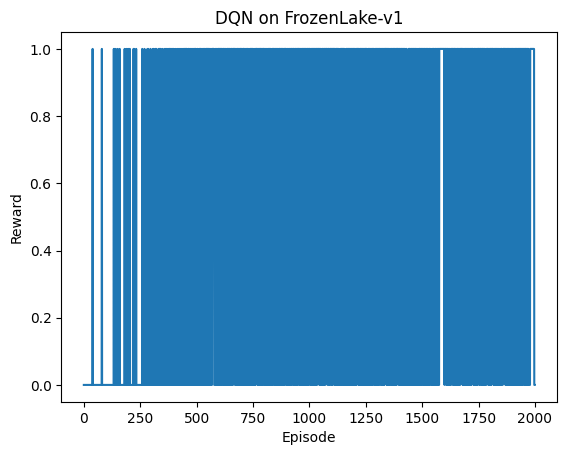

In [9]:
q_net, rewards = train_dqn(episodes=2000)

plt.plot(rewards)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("DQN on FrozenLake-v1")
plt.show()

## Step 7: Record Multiple Episodes as Video

We now let the trained agent play **5 episodes** and record them into one video.  
This way we can see if the policy is consistent or just lucky.


In [10]:
env = gym.make("FrozenLake-v1", render_mode="rgb_array")
state_size = env.observation_space.n

def one_hot(s):
    vec = np.zeros(state_size)
    vec[s] = 1.0
    return vec

video_path = "frozenlake_dqn.mp4"
writer = imageio.get_writer(video_path, fps=3)

state, _ = env.reset()
done = False
total_reward = 0

while not done:
    state_vec = torch.FloatTensor(one_hot(state))
    with torch.no_grad():
        action = torch.argmax(q_net(state_vec)).item()

    next_state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    total_reward += reward

    frame = env.render()
    writer.append_data(frame)

    state = next_state

writer.close()
env.close()
print(f"Video saved to {video_path}, total reward = {total_reward}")


Video saved to frozenlake_dqn.mp4, total reward = 1.0


In [12]:
import imageio

env = gym.make("FrozenLake-v1", render_mode="rgb_array")
state_size = env.observation_space.n

def one_hot(s):
    vec = np.zeros(state_size)
    vec[s] = 1.0
    return vec

video_path = "frozenlake_dqn_multi.mp4"
writer = imageio.get_writer(video_path, fps=3)

num_episodes = 5
for ep in range(num_episodes):
    state, _ = env.reset()
    done = False
    total_reward = 0
    print(f"Recording episode {ep+1}")

    while not done:
        state_vec = torch.FloatTensor(one_hot(state))
        with torch.no_grad():
            action = torch.argmax(q_net(state_vec)).item()

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        total_reward += reward

        frame = env.render()
        writer.append_data(frame)

        state = next_state

    print(f"Episode {ep+1} finished with reward {total_reward}")

writer.close()
env.close()
print(f"Multi-episode video saved to {video_path}")


Recording episode 1
Episode 1 finished with reward 1.0
Recording episode 2
Episode 2 finished with reward 1.0
Recording episode 3
Episode 3 finished with reward 1.0
Recording episode 4
Episode 4 finished with reward 1.0
Recording episode 5
Episode 5 finished with reward 1.0
Multi-episode video saved to frozenlake_dqn_multi.mp4


## 8. Watch the video

In [13]:
Video("frozenlake_dqn_multi.mp4", embed=True)


## Evaluate Agent

In [14]:
def evaluate_agent(env, q_net, episodes=100):
    state_size = env.observation_space.n
    def one_hot(s):
        vec = np.zeros(state_size)
        vec[s] = 1.0
        return vec

    total_rewards = 0
    for _ in range(episodes):
        state, _ = env.reset()
        done = False
        while not done:
            state_vec = torch.FloatTensor(one_hot(state))
            with torch.no_grad():
                action = torch.argmax(q_net(state_vec)).item()
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_rewards += reward
    return total_rewards / episodes

# Run evaluation
eval_env = gym.make("FrozenLake-v1", is_slippery=True)
success_rate = evaluate_agent(eval_env, q_net, episodes=100)
print(f"✅ Agent success rate over 100 episodes: {success_rate*100:.2f}%")
eval_env.close()


✅ Agent success rate over 100 episodes: 73.00%
